<a href="https://colab.research.google.com/github/customerdelightgroup/customerdelight/blob/GroupCode/v2_delighting_the_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAN200 – Group Project April 6th, 2026


Project Title: Building a Customer Delight Model

Prepared for: Professor Roya Barzegar

Prepared by:
Meg Smith
Lazar Todorovic
Dare Emmanuel
Dalia Al Tom
Bolanle Emmanuel

1.0 Data Loading and Combining

Load three text-based sentiment datasets provided by the UCI Machine Learning Repository
- Amazon product reviews
- IMDB movie reviews
- Yelp business reviews
Each contains 1000 labeled sentences indicating sentiment is positive(1) or negative(0)

We are using three datasets and combining them into a single more diverse dataset of 2748 samples to ensure it learns sentiment patterns across different domains: movies, products, and local business.

In [ ]:
# import needed libraries
import pandas as pd
import nltk
import re
from collections import Counter

# download stopwords if not already installed
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import pandas as pd

# load all three datasets: Amazon, IMDB, yelp
amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["sentence", "label"])
imdb = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["sentence", "label"])
yelp = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["sentence", "label"])

# combine them into one dataframe
df = pd.concat([amazon, imdb, yelp], ignore_index=True)

# view first few rows
df.head()


,sentence,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


1.1 Dataset Balance Check

Comfirm that the dataset contains equal number of positve and negative reviews, for fair model training.

In [ ]:
print(df["label"].value_counts())



label
1    1386
0    1362
Name: count, dtype: int64


The dataset is nearly balanced with 1386 positve reviews and 1362 negative reviews; leaving only a small difference between positve and negative labels.

2.0 Cleaning the Text Data

Prepare data by:
- convert all text to lowercase
- remove punctuation and non-letters
- remove extra spaces

In [ ]:
# cleans sentence so model can understand better: remove punctuation, and making lower case
def clean_text(text):
    text = text.lower()                                # make all letters lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)            # remove punctuation and special characters
    text = re.sub(r"\s+", " ", text).strip()           # remove extra spaces
    return text

# apply cleaning to every sentence in the dataset
df["clean_sentence"] = df["sentence"].apply(clean_text)

# view first few cleaned sentences
df[["sentence", "clean_sentence"]].head()


,sentence,clean_sentence
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...
4,The mic is great.,the mic is great


3.0 Tokenization and Stopword Removal

Each sentence is split into individual words (tokens).  We remove common English stopwords ie. the, is, and; because they are not meaningful in the data.  But, we will keep no, and not because they play a role in negative sentiment.

In [ ]:
from nltk.corpus import stopwords

# load list of common English stopwords ie. the, is, and
stop_words = set(stopwords.words("english"))

# remove "no" and "not" from the stopword list because they affect sentiment
stop_words = {w for w in stop_words if w not in ["no", "not"]}

# tokenize each cleaned sentence into individual words and remove stopword
def tokenize(sentence):
    tokens = sentence.split()                          # split the sentence into words
    tokens = [t for t in tokens if t not in stop_words] # remove stopwords
    return tokens

# apply tokenization to every cleaned sentence
df["tokens"] = df["clean_sentence"].apply(tokenize)

# view first few tokenized sentences
df[["clean_sentence", "tokens"]].head()


,clean_sentence,tokens
0,so there is no way for me to plug it in here i...,"[no, way, plug, us, unless, go, converter]"
1,good case excellent value,"[good, case, excellent, value]"
2,great for the jawbone,"[great, jawbone]"
3,tied to charger for conversations lasting more...,"[tied, charger, conversations, lasting, minute..."
4,the mic is great,"[mic, great]"


4.0 Word Counts

Calculate the number of tokens in each sentence to understand the distribution of sentence lengths across the dataset.  

This will help to identify if positive or negative reviews tend to be longer or shorter.  

In [ ]:
# count words in each token list
df["word_count"] = df["tokens"].apply(len)

# view first few tokens with their word count
df[["tokens", "word_count"]].head()


,tokens,word_count
0,"[no, way, plug, us, unless, go, converter]",7
1,"[good, case, excellent, value]",4
2,"[great, jawbone]",2
3,"[tied, charger, conversations, lasting, minute...",6
4,"[mic, great]",2


5.0 Text Mining: Word Frequencies

Uncover drivers of customer sentiment by counting how often each word appears in positive vs negative sentences.  

From this we will see: words strongly associated with positive ie. great, good; or words strongly associated with negative ie. not, bad,


In [ ]:
# create counters to store word frequencies for positive and negative reviews
positive_words = Counter()   # store words positive sentences
negative_words = Counter()   # store words negative sentences

# scan each row in dataset and update correct number
for _, row in df.iterrows():
    if row["label"] == 1:                     # if positive review
        positive_words.update(row["tokens"])  # add words to positive counter
    else:                                     #  if negative review
        negative_words.update(row["tokens"])  # add words to negative counter

# view top 10 most common words in each group
positive_words.most_common(10), negative_words.most_common(10)


([('great', 190),
  ('good', 172),
  ('phone', 86),
  ('movie', 84),
  ('film', 84),
  ('one', 68),
  ('really', 60),
  ('food', 60),
  ('best', 59),
  ('like', 58)],
 [('not', 252),
  ('movie', 93),
  ('bad', 92),
  ('phone', 76),
  ('one', 75),
  ('film', 71),
  ('dont', 66),
  ('like', 65),
  ('food', 64),
  ('no', 62)])

6.0 Text Mining: Bigrams

Some sentiment cues come from two word phrases such as:
- not good
- customer service
- works great

In [ ]:
from nltk import bigrams

# create bigrams for each token list
def get_bigrams(tokens):
    return list(bigrams(tokens))

# apply bigram extraction to each sentence
df["bigrams"] = df["tokens"].apply(get_bigrams)

# count all bigrams across the dataset
all_bigrams = Counter()
for bg_list in df["bigrams"]:
    all_bigrams.update(bg_list)

# view 10 most common bigrams
all_bigrams.most_common(10)


[(('not', 'good'), 22),
 (('go', 'back'), 18),
 (('works', 'great'), 17),
 (('waste', 'time'), 17),
 (('would', 'not'), 16),
 (('customer', 'service'), 14),
 (('ive', 'ever'), 14),
 (('sound', 'quality'), 13),
 (('could', 'not'), 13),
 (('one', 'best'), 13)]

7.0  Feature Engineering with TF-IDF

Convert each sentence into vector using Term Frequency-Inverse Document Frequency (TF-IDF).  Therefore, TF-IDF assigns higher weight to words that are:
- frequent in specific sentences
- rare across the dataset

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF turns text into numbers based on how important a word is
vectorizer = TfidfVectorizer()

# fit vectorizer on cleaned sentences and transform into a matrix
X = vectorizer.fit_transform(df["clean_sentence"])

# store our sentiment labels (0 = negative, 1 = positive)
y = df["label"]

# show the shape of the TF-IDF matrix
print("TF-IDF matrix shape:", X.shape)

# show how many unique words (features) TF-IDF learned
print("Number of features:", len(vectorizer.vocabulary_))

# show the first 10 feature names learned by TF-IDF
feature_names = vectorizer.get_feature_names_out()
print("First 10 TF-IDF features:")
for word in feature_names[:10]:
    print("-", word)



TF-IDF matrix shape: (2748, 5283)
Number of features: 5283
First 10 TF-IDF features:
- aailiyah
- abandoned
- abhor
- ability
- able
- abound
- about
- above
- abovepretty
- abroad


TF‑IDF vectorizer successfully converted cleaned sentences into numerical features.
The matrix shape shows how many sentences and unique words the model is using:

2748 rows = number of sentences after cleaning

5283 columns = number of unique words learned

8.0 Train/Test Split

To evaluate the model we split dataset into
- 80% training data - to teach
- 20% testing data - to measure performance


In [ ]:
from sklearn.model_selection import train_test_split

# split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# view shapes of train and test sets
X_train.shape, X_test.shape


((2198, 5283), (550, 5283))

The shapes show that 2,198 samples were used for training and 550 were held for testing, each with 5,283 TF‑IDF features.

9.0 Model Training (Naive Bayes and Logistic Regression)

We train two learning models to compare performance:
Multinomial Naive Bayes
- fast and effective for text classification

Logistic Regression
- flexible and powerful

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# create the Naive Bayes model
nb_model = MultinomialNB()

# train the model
nb_model.fit(X_train, y_train)

# make predictions on the test set
nb_predictions = nb_model.predict(X_test)

print("Naive Bayes model trained successfully.")
print("Sample predictions:", nb_predictions[:10])

Naive Bayes model trained successfully.
Sample predictions: [1 1 0 0 0 0 0 1 0 0]


In [ ]:
from sklearn.linear_model import LogisticRegression

# create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# train the model
lr_model.fit(X_train, y_train)

# make predictions on the test set
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")
print("Sample predictions:", lr_predictions[:10])

Logistic Regression model trained successfully.
Sample predictions: [1 1 0 0 0 0 0 1 0 0]


10.0 Model Evaluation

Evaluate the model using the following:
- accuracy: overall correctness
- precision: how often positive predictions are correct
- recall: how well model identifies actual positives
- confusion matrix: breakdown true or false, positives and negatives

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# evaluate Naive Bayes
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))
print("Naive Bayes Precision:", precision_score(y_test, nb_predictions))
print("Naive Bayes Recall:", recall_score(y_test, nb_predictions))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, nb_predictions))

# evaluate Logistic Regression
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("Logistic Regression Precision:", precision_score(y_test, lr_predictions))
print("Logistic Regression Recall:", recall_score(y_test, lr_predictions))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, lr_predictions))


Naive Bayes Accuracy: 0.8163636363636364
Naive Bayes Precision: 0.7862318840579711
Naive Bayes Recall: 0.8378378378378378
Naive Bayes Confusion Matrix:
 [[232  59]
 [ 42 217]]

Logistic Regression Accuracy: 0.8163636363636364
Logistic Regression Precision: 0.8038461538461539
Logistic Regression Recall: 0.806949806949807
Logistic Regression Confusion Matrix:
 [[240  51]
 [ 50 209]]


10.1 Model Comparison Table

Displays the accuracy, precisions, recall and false positives between the Naive Bayes and Logistic Regression.


In [ ]:
import pandas as pd

# create a dictionary with model metrics
data = {
    "metric": ["accuracy", "precision", "recall", "false positives", "false negatives"],
    "naive_bayes": [0.816, 0.786, 0.838, 59, 42],
    "logistic_regression": [0.816, 0.804, 0.807, 51, 50]
}

# convert to dataframe
comparison_df = pd.DataFrame(data)

# display table
comparison_df


,metric,naive_bayes,logistic_regression
0,accuracy,0.816,0.816
1,precision,0.786,0.804
2,recall,0.838,0.807
3,false positives,59.000,51.000
4,false negatives,42.000,50.000


Naive Bayes
Confusion Matrix Results:
232 true negatives
217 true positives
59 false positives
42 false negatives

Conclusion: Naive Bayes is slightly better at recall, meaning it catches more positive reviews, but it makes more false positives. Therefore, it is better at recall becuase it catches more positives.

Logistic Regression
Confusion Matrix Results:
240 true negatives
209 true positives
51 false positives
50 false negatives

Conclusion:  Logistic Regression is more balanced with less false positives, slightly more false negatives. Therefore, better at precision because it makes fewer mistakes.

Both models have the same accuracy (0.816)

11.0 Misclassification

To understand model limitations look at misclassification examples which include:
- sentences with sarcasm
- wording is unclear
- review includes mixed sentiment (positive and negative)
- model relies on key words and not context

Note: In order to understand where the models have difficulty, need to extract the sentences that were misclassified.  This includes cases where the predicted label does not match the true label.

Misclassifications often happen because of unclear wording, sarcasm, mixed sentiment, or sentences which rely on context the model cannot understand. Looking into these examples helped us identify the limitations in the model and the opportunities for improvement.


In [ ]:

import numpy as np

# get original dataframe indices for the test set
test_indices = y_test.index

# find incidents where Naive Bayes predictions were wrong
nb_wrong = np.where(nb_predictions != y_test)[0]

# view sample misclassified sentences for Naive Bayes
print("Naive Bayes – Sample Misclassified Sentences:\n")
for i in nb_wrong[:10]:  # show first 10
    original_index = test_indices[i]
    print(f"Sentence: {df.loc[original_index, 'sentence']}")
    print(f"True Label: {y_test.iloc[i]}, Predicted: {nb_predictions[i]}")
    print("-" * 80)

# find incidents where logistic Regression predictions were wrong
lr_wrong = np.where(lr_predictions != y_test)[0]

# view sample misclassified sentences for logistic regression
print("\nLogistic Regression – Sample Misclassified Sentences:\n")
for i in lr_wrong[:10]:  # show first 10
    original_index = test_indices[i]
    print(f"Sentence: {df.loc[original_index, 'sentence']}")
    print(f"True Label: {y_test.iloc[i]}, Predicted: {lr_predictions[i]}")
    print("-" * 80)


Naive Bayes – Sample Misclassified Sentences:

Sentence: Any grandmother can make a roasted chicken better than this one.
True Label: 0, Predicted: 1
--------------------------------------------------------------------------------
Sentence: High-quality chicken on the chicken Caesar salad.
True Label: 1, Predicted: 0
--------------------------------------------------------------------------------
Sentence: Restaurant is always full but never a wait.
True Label: 1, Predicted: 0
--------------------------------------------------------------------------------
Sentence: And the beans and rice were mediocre at best.
True Label: 0, Predicted: 1
--------------------------------------------------------------------------------
Sentence: The deal included 5 tastings and 2 drinks, and Jeff went above and beyond what we expected.
True Label: 1, Predicted: 0
--------------------------------------------------------------------------------
Sentence: The internet access was fine, it the rare instance 

12.0 Customer Delight Insights

Understand drivers of customer delight and dissatisfaction.  Using the text-mining results to identify themes and language patterns that appear in positive and negative reviews.  

Positive Sentiment Drivers Customer Delight

Words such as great, good, excellent, best, really, and like frequently appear in positive reviews and suggest customers express delight when:
- the product or service performs reliably
- quality exceeds expectations
- the experience is enjoyable or convenient
- the value feels high

Positive Bigrams like “works great” reinforce functionality and performance and are contributors to satisfaction.

Negative Sentiment Drivers are Customer Pain Points
Negative reviews commonly include words like not, bad, waste, don't, no, and could not and these indicate dissatisfaction driven by:
- poor performance or reliability
- frustration with usability
- service failures
- low perceived value


Negative Bigrams such as “not good” and “customer service” show issues which businesses should address.

Business Value

These insights help organizations:
- identify what customers appreciate most
- detect recurring problems
- prioritize improvements
- monitor sentiment trends over time

This is the foundation of a Customer Delight Model, where sentiment signals guide strategic decisions to have a positive customer experience.

13.0 Option Visualizations

The following charts are being included:
- bar chart: of most common and negative words
- bigram frequency chart: to show common sentiment phrases
- confusion matrix heatmaps: to visualize model performance
- word clouds: quick visual summaries of sentiment drivers

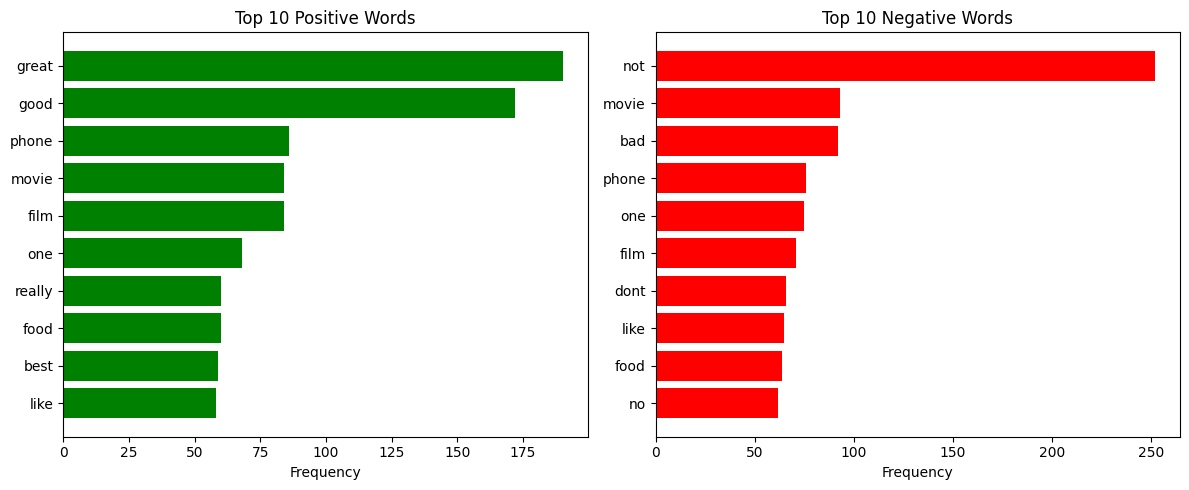

In [ ]:
import matplotlib.pyplot as plt

# top 10 positive and negative words
top_pos = positive_words.most_common(10)
top_neg = negative_words.most_common(10)

# split words and counts for plotting
pos_words, pos_counts = zip(*top_pos)
neg_words, neg_counts = zip(*top_neg)

# plot top positive and negative words
plt.figure(figsize=(12, 5))

# plot positive words
plt.subplot(1, 2, 1)
plt.barh(pos_words, pos_counts, color='green')
plt.title("Top 10 Positive Words")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()

# plot negative words
plt.subplot(1, 2, 2)
plt.barh(neg_words, neg_counts, color='red')
plt.title("Top 10 Negative Words")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()

# adjust spaces and show the plot
plt.tight_layout()
plt.show()

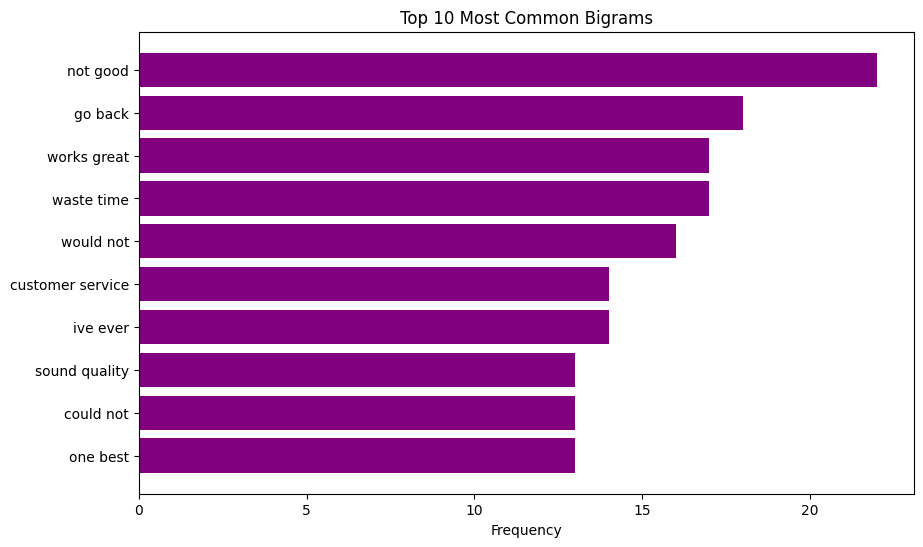

In [ ]:
# top 10 bigrams
top_bigrams = all_bigrams.most_common(10)
bigram_labels = [' '.join(bg[0]) for bg in top_bigrams]
bigram_counts = [bg[1] for bg in top_bigrams]

# plot most common bigrams
plt.figure(figsize=(10, 6))
plt.barh(bigram_labels, bigram_counts, color='purple')
plt.title("Top 10 Most Common Bigrams")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()


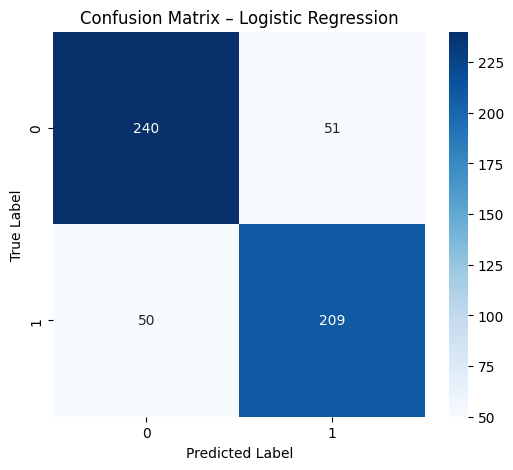

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_predictions)

# plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In conclusion, both models perform similarly but Logistic Regression provides more balanced precision and recall.  The text-mining insights highlight clear drivers of customer delight and dissatisfaction, supporting the development of a Customer Delight Model.  

14.0 Limitations of the Customer Delight Model

Model limitations

Our sentiment models work well overall, but there are several limitations that affect accuracy and interpretation:

- sarcasm and indirect language: the models rely on literal word patterns, which means sarcastic sentences are misclassified as positive.

- mixed or subtle sentiment: reviews that contain both praise and criticism confuse the models because TF‑IDF treats each word independently.

- context loss: bag‑of‑words and TF‑IDF ignore tone, intent, and sentence structure and phrases like “mediocre at best” have positive words but also have a negative meaning.

- domain differences: the dataset combines Amazon, IMDB, and Yelp reviews and language patterns differ across domains, which the model cannot fully adapt to these changes.

- limited vocabulary understanding: the models cannot interpret slang, exaggeration, or emotional nuance unless those patterns appear frequently in the training data.

- no understanding of intensity: both models treat “bad” and “terrible” as similar even though the emotional strength is different.

- impact: these limitations explain many of the misclassifications and show why a more advanced model might perform better for a Customer Delight System.